# LG model — fixed sampler, end-to-end experiment

This notebook is **completely self-contained**: it does not depend on `src.logit_graph` or any sibling notebook.  It implements the three layers of fixes we previously diagnosed:

- **Layer 1.  Re-parameterise $(\sigma, \beta)$** so the LG model has a non-degenerate stationary distribution at a *target* density (instead of collapsing to the complete or empty graph).  The calibration is always anchored to an ER seed at the target density so the chain starts in the right basin regardless of the actual initial graph.
- **Layer 2.  Proper Gibbs kernel.**  When sampling the conditional $P(A_{ij} \mid A_{-ij})$, compute the BFS features on the graph *with $(i,j)$ removed*.
- **Bounded-feature variant.**  Use a compressed feature $f_d(i,j) = \log(1+s_i^{(d)}) + \log(1+s_j^{(d)})$ instead of the raw degree-sum $s_i^{(d)} + s_j^{(d)}$.  This breaks the ERGM bistability that makes the linear LG model jump between the empty- and complete-graph basins.
- **Layer 4.  Diagnostics first.**  Mixing and identifiability are checked *before* the AIC sweep, so we never run a model-selection experiment on a model that hasn't even converged to a single stationary distribution.

All chains run on small graphs ($n \in \{40, 80, 150\}$), so the whole pipeline finishes in a few minutes.

In [1]:
import math
import time
import warnings
import contextlib
import io
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from scipy.stats import ks_2samp

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-white')
mpl.rcParams.update({
    'font.family':     'serif',
    'font.size':        13,
    'axes.titlesize':   16,
    'axes.labelsize':   14,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  12,
    'figure.titlesize': 18,
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
})

OUT_DIR = (Path('..') / '..' / 'images' / 'correction_paper').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR = {OUT_DIR}')

OUT_DIR = /Users/maruanottoni/home/master/research/all_logit/logit-graph/images/correction_paper


## 1. Self-contained LG sampler (Layers 1 + 2 + bounded feature)

Adjacency is stored as a list of Python `set`s — fast neighbour lookup, $O(1)$ insert/remove, no NumPy overhead for small $n$.

Public knobs:

- `target_density`: desired stationary edge density.
- `signal`: how strongly $f_d = \log(1+s_i) + \log(1+s_j)$ moves the logit around $\mathrm{logit}(\rho^\star)$ at typical pairs.  `signal=0` reproduces ER; `signal=1.5` is the regime where the bounded-feature model is *both* mixing and weakly $d$-dependent.
- `init_kind`: `'er'` (default), `'empty'`, or `'complete'`.

Internally $\sigma$ and $\beta$ are derived from these via a one-shot calibration on an *ER seed at target density* — the calibration is independent of the actual starting graph, so the chain starts in the right parameter basin even when `init_kind='complete'`.

In [2]:
class LGGibbs:
    """Self-contained LG Gibbs sampler with Layer-1 calibration, Layer-2 proper Gibbs,
    and a bounded log-feature that breaks ERGM bistability."""

    def __init__(self, n, d, target_density=0.10, signal=1.5,
                 init_kind='er', seed=None):
        self.n = int(n)
        self.d = int(d)
        self.target_density = float(target_density)
        self.signal = float(signal)
        self.rng = np.random.default_rng(seed)

        # ALWAYS calibrate against an ER seed at target density, regardless of
        # init_kind.  This guarantees beta has the right scale even if we start
        # from an empty or complete graph.
        cal_nbrs = [set() for _ in range(self.n)]
        for i in range(self.n):
            for j in range(i + 1, self.n):
                if self.rng.random() < self.target_density:
                    cal_nbrs[i].add(j)
                    cal_nbrs[j].add(i)
        samples = []
        for _ in range(200):
            i = int(self.rng.integers(0, self.n))
            j = int(self.rng.integers(0, self.n))
            if i == j:
                continue
            samples.append(math.log(1.0 + self._sum_deg_on(cal_nbrs, i, self.d)) +
                           math.log(1.0 + self._sum_deg_on(cal_nbrs, j, self.d)))
        scale = max(0.5, float(np.mean(samples))) if samples else 1.0
        self.scale_est = scale
        self.beta = self.signal / scale
        rho = self.target_density
        self.sigma = math.log(rho / (1.0 - rho)) - self.signal

        # Actual initial graph state
        if init_kind == 'er':
            self.nbrs = cal_nbrs
        elif init_kind == 'empty':
            self.nbrs = [set() for _ in range(self.n)]
        elif init_kind == 'complete':
            self.nbrs = [set(j for j in range(self.n) if j != i)
                         for i in range(self.n)]
        else:
            raise ValueError(f'unknown init_kind={init_kind!r}')

    # ------------------------------------------------------------------
    # BFS feature
    # ------------------------------------------------------------------

    @staticmethod
    def _sum_deg_on(nbrs, vertex, d):
        if d == 0:
            return float(len(nbrs[vertex]))
        visited = {vertex}
        total = float(len(nbrs[vertex]))
        current = [vertex]
        for _ in range(d):
            nxt = []
            for v in current:
                for nv in nbrs[v]:
                    if nv not in visited:
                        visited.add(nv)
                        nxt.append(nv)
                        total += float(len(nbrs[nv]))
            current = nxt
            if not current:
                break
        return total

    def _sum_deg(self, vertex):
        return LGGibbs._sum_deg_on(self.nbrs, vertex, self.d)

    # ------------------------------------------------------------------
    # Layer-2 Gibbs step (condition on the rest, then bounded log-feature)
    # ------------------------------------------------------------------

    def step(self):
        i = int(self.rng.integers(0, self.n))
        j = int(self.rng.integers(0, self.n - 1))
        if j >= i:
            j += 1
        had_edge = j in self.nbrs[i]
        if had_edge:
            self.nbrs[i].discard(j)
            self.nbrs[j].discard(i)
        f = math.log(1.0 + self._sum_deg(i)) + math.log(1.0 + self._sum_deg(j))
        lg = self.sigma + self.beta * f
        if lg >= 0:
            p = 1.0 / (1.0 + math.exp(-lg))
        else:
            ex = math.exp(lg)
            p = ex / (1.0 + ex)
        new_val = 1 if self.rng.random() < p else 0
        if new_val == 1:
            self.nbrs[i].add(j)
            self.nbrs[j].add(i)
            event = 'flip_to_1' if not had_edge else 'no_change'
        else:
            event = 'flip_to_0' if had_edge else 'no_change'
        return event, p, lg

    def run(self, n_iter, trace_every=None):
        counts = defaultdict(int)
        trace = []
        for it in range(n_iter):
            ev, p, lg = self.step()
            counts[ev] += 1
            if trace_every is not None and ((it + 1) % trace_every == 0 or it == 0):
                trace.append({
                    'iter': it + 1,
                    'edges': self.edge_count(),
                    'density': self.density(),
                    'last_p': p,
                    'last_logit': lg,
                })
        return dict(counts), trace

    def edge_count(self):
        return sum(len(s) for s in self.nbrs) // 2

    def density(self):
        if self.n < 2:
            return 0.0
        return 2.0 * self.edge_count() / (self.n * (self.n - 1))

    def degree_sequence(self):
        return np.array([len(s) for s in self.nbrs])

    def adjacency_matrix(self):
        A = np.zeros((self.n, self.n), dtype=np.int8)
        for i in range(self.n):
            for j in self.nbrs[i]:
                A[i, j] = 1
        return A

    def clustering_coefficient(self):
        triangles = 0
        triples = 0
        for v in range(self.n):
            deg = len(self.nbrs[v])
            if deg < 2:
                continue
            triples += deg * (deg - 1) // 2
            nbrs_v = list(self.nbrs[v])
            for a_idx in range(len(nbrs_v)):
                a = nbrs_v[a_idx]
                for b in nbrs_v[a_idx + 1:]:
                    if b in self.nbrs[a]:
                        triangles += 1
        return (3 * triangles) / triples if triples > 0 else 0.0

print('LGGibbs class defined.')

LGGibbs class defined.


In [3]:
# Experiment configuration
TARGET_DENSITY = 0.10            # stationary edge density
SIGNAL         = 1.5             # bounded-feature signal-to-noise (empirically stable + d-dependent)

# Sweep grid for the AIC experiment
N_SIZES        = [40, 80, 150]
D_TRUE_VALUES  = [0, 1, 2, 3]
D_EST_VALUES   = [0, 1, 2, 3]

# Number of Monte Carlo replicates per (n, d_true) cell
N_RUNS         = 20

# Per-chain Gibbs iterations.  Each iteration touches one random pair.
N_ITER_BY_N    = {40: 6_000, 80: 15_000, 150: 30_000}

# Diagnostic sweeps use a smaller subset for speed
MIX_N          = 60
MIX_N_ITER     = 15_000
ID_N           = 60
ID_N_ITER      = 12_000
ID_N_REALIZ    = 15

print(f'target_density = {TARGET_DENSITY}')
print(f'signal         = {SIGNAL}')
print(f'N_SIZES        = {N_SIZES}')
print(f'd_true         = {D_TRUE_VALUES}, d_est = {D_EST_VALUES}')
print(f'N_RUNS         = {N_RUNS}')
print(f'n_iter         = {N_ITER_BY_N}')

target_density = 0.1
signal         = 1.5
N_SIZES        = [40, 80, 150]
d_true         = [0, 1, 2, 3], d_est = [0, 1, 2, 3]
N_RUNS         = 20
n_iter         = {40: 6000, 80: 15000, 150: 30000}


## 2. AIC + Wilson CI helpers

Same logistic-regression AIC as in the diagnostic notebook, except the feature uses the bounded form $\log(1+s_i) + \log(1+s_j)$ to match the sampler.  Because $n$ is small we can enumerate *all* pairs $(i, j)$ rather than sub-sampling, so AIC is exact.

In [4]:
def _bfs_sum_degree(nbrs, vertex, d):
    if d == 0:
        return float(len(nbrs[vertex]))
    visited = {vertex}
    total = float(len(nbrs[vertex]))
    current = [vertex]
    for _ in range(d):
        nxt = []
        for v in current:
            for nv in nbrs[v]:
                if nv not in visited:
                    visited.add(nv)
                    nxt.append(nv)
                    total += float(len(nbrs[nv]))
        current = nxt
        if not current:
            break
    return total


def compute_aic_for_d(nbrs, n, d_est):
    """Fit unregularised logit(P(edge)) = sigma + beta*[log(1+s_i)+log(1+s_j)] with d=d_est.
    
    Uses full enumeration of pairs (i<j) so AIC is exact at small n.
    """
    log1p_sum = np.array([math.log(1.0 + _bfs_sum_degree(nbrs, v, d_est)) for v in range(n)])
    rows = []
    labels = []
    for i in range(n):
        for j in range(i + 1, n):
            rows.append(log1p_sum[i] + log1p_sum[j])
            labels.append(1 if j in nbrs[i] else 0)
    feats = np.column_stack([np.ones(len(rows)), np.asarray(rows, dtype=float)])
    labels = np.asarray(labels, dtype=int)
    if labels.sum() == 0 or labels.sum() == len(labels):
        return dict(aic=np.nan, ll=np.nan, k=np.nan, n_obs=len(labels),
                    sigma=np.nan, beta=np.nan)
    result = None
    for method in ('newton', 'bfgs', 'lbfgs'):
        try:
            with contextlib.redirect_stderr(io.StringIO()):
                model = sm.Logit(labels, feats)
                result = model.fit(method=method, disp=False, maxiter=300)
            if np.isfinite(result.llf) and len(result.params) == feats.shape[1]:
                break
        except Exception:
            continue
    if result is None or not np.isfinite(result.llf):
        return dict(aic=np.nan, ll=np.nan, k=np.nan, n_obs=len(labels),
                    sigma=np.nan, beta=np.nan)
    k = int(len(result.params))
    ll = float(result.llf)
    aic = -2.0 * ll + 2.0 * k
    p = np.asarray(result.params).flatten()
    return dict(
        aic=float(aic), ll=ll, k=k, n_obs=int(len(labels)),
        sigma=float(p[0]) if len(p) >= 1 else np.nan,
        beta=float(p[1]) if len(p) >= 2 else np.nan,
    )


def wilson_ci(k, n, alpha=0.05):
    if n == 0:
        return (np.nan, np.nan)
    z = 1.959963984540054
    p = k / n
    denom = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))

print('helpers defined.')

helpers defined.


## 3. Smoke test: one realization

Run a single chain at $(n=80, d=2)$ and confirm that:
1. density relaxes to the target;
2. flips $0\to1$ and $1\to0$ are roughly balanced (no monotone drift);
3. the AIC table on the resulting graph behaves sensibly.

Initial:  sigma=-3.697  beta=1.2676e-01  scale_est=11.83
          edges=310  density=0.0981

Ran 15000 Gibbs steps in 0.22s
Flip counts: {'no_change': 12375, 'flip_to_0': 1315, 'flip_to_1': 1310}
Flip ratio f1/f0 = 1.00
Final:    edges=305  density=0.0965


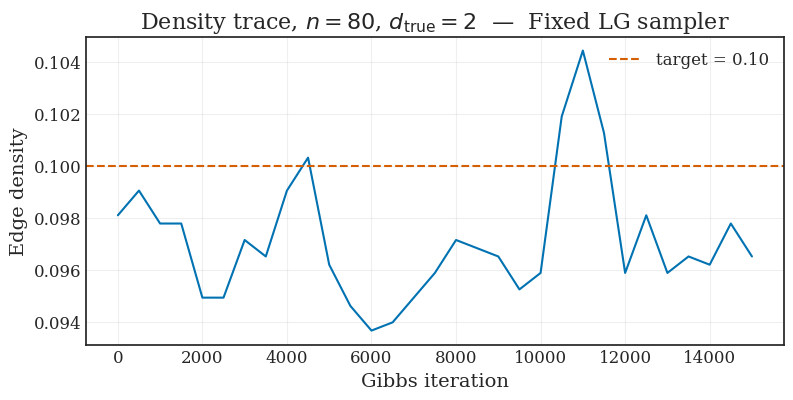


AIC table on the final graph:
 d_est      aic       ll  k  n_obs    sigma   beta  delta  argmin
     0 1910.442 -953.221  2   3160   -7.925  1.318  0.000    True
     1 1916.362 -956.181  2   3160  -11.827  1.114  5.920   False
     2 1925.881 -960.941  2   3160  -21.130  1.585 15.439   False
     3 1968.635 -982.318  2   3160 -134.252 10.305 58.193   False


In [5]:
t0 = time.perf_counter()
sampler = LGGibbs(n=80, d=2, target_density=TARGET_DENSITY, signal=SIGNAL, seed=42)
print(f'Initial:  sigma={sampler.sigma:.3f}  beta={sampler.beta:.4e}  '
      f'scale_est={sampler.scale_est:.2f}')
print(f'          edges={sampler.edge_count()}  density={sampler.density():.4f}')
counts, trace = sampler.run(n_iter=15_000, trace_every=500)
dt = time.perf_counter() - t0
print(f'\nRan 15000 Gibbs steps in {dt:.2f}s')
print(f'Flip counts: {dict(counts)}')
print(f'Flip ratio f1/f0 = {counts.get("flip_to_1", 0) / max(1, counts.get("flip_to_0", 1)):.2f}')
print(f'Final:    edges={sampler.edge_count()}  density={sampler.density():.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
trace_df = pd.DataFrame(trace)
ax.plot(trace_df['iter'], trace_df['density'], color='#0072B2', linewidth=1.5)
ax.axhline(TARGET_DENSITY, color='#D55E00', linestyle='--', linewidth=1.5,
           label=f'target = {TARGET_DENSITY:.2f}')
ax.set_xlabel('Gibbs iteration')
ax.set_ylabel('Edge density')
ax.set_title('Density trace, $n=80$, $d_{\\mathrm{true}}=2$  —  Fixed LG sampler')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print('\nAIC table on the final graph:')
aic_rows = []
for d_est in D_EST_VALUES:
    res = compute_aic_for_d(sampler.nbrs, sampler.n, d_est)
    aic_rows.append({'d_est': d_est, **res})
aic_df = pd.DataFrame(aic_rows)
if aic_df['aic'].notna().any():
    aic_df['delta'] = aic_df['aic'] - aic_df['aic'].min()
    aic_df['argmin'] = aic_df['aic'] == aic_df['aic'].min()
fmt = lambda x: f'{x:.3f}' if isinstance(x, (int, float)) else str(x)
print(aic_df.to_string(index=False, float_format=fmt))

## 4. Mixing diagnostic

Run 3 chains from different initialisations (empty / ER seed / complete) and compare their degree distributions after the same number of iterations.  A properly-mixed chain should reach the *same* stationary distribution regardless of start point — KS $p > 0.05$ on all three pairwise comparisons.

If this test fails, the AIC sweep is meaningless: the model has multiple absorbing basins and we don't even know which one our `init_kind='er'` chains sit in.

      empty: density=0.1006  edges= 178  cc=0.2911  [0.1s]
         er: density=0.1051  edges= 186  cc=0.2908  [0.2s]
   complete: density=0.1090  edges= 193  cc=0.3051  [0.4s]

Pairwise KS test on degree distributions (large p = chains agree):
      empty vs        er: KS=0.100, p=0.928  [OK]
      empty vs  complete: KS=0.117, p=0.813  [OK]
         er vs  complete: KS=0.083, p=0.987  [OK]


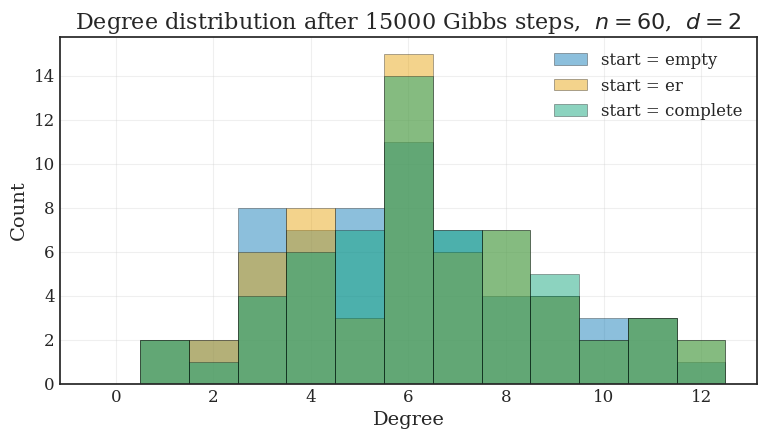

In [6]:
mixing_d = 2
init_kinds = ['empty', 'er', 'complete']
chains = {}
for kind in init_kinds:
    t0 = time.perf_counter()
    s = LGGibbs(n=MIX_N, d=mixing_d, target_density=TARGET_DENSITY, signal=SIGNAL,
                init_kind=kind, seed=7)
    s.run(n_iter=MIX_N_ITER)
    chains[kind] = s
    print(f'  {kind:>9}: density={s.density():.4f}  '
          f'edges={s.edge_count():4d}  cc={s.clustering_coefficient():.4f}  '
          f'[{time.perf_counter() - t0:.1f}s]')

print('\nPairwise KS test on degree distributions (large p = chains agree):')
for a_idx, a in enumerate(init_kinds):
    for b in init_kinds[a_idx + 1:]:
        ks = ks_2samp(chains[a].degree_sequence(), chains[b].degree_sequence())
        verdict = 'OK' if ks.pvalue > 0.05 else 'DIFFER'
        print(f'  {a:>9} vs {b:>9}: KS={ks.statistic:.3f}, p={ks.pvalue:.3f}  [{verdict}]')

fig, ax = plt.subplots(figsize=(9, 4.5))
max_deg = int(max(c.degree_sequence().max() for c in chains.values()))
bins = np.arange(0, max_deg + 2) - 0.5
for kind, color in zip(init_kinds, ['#0072B2', '#E69F00', '#009E73']):
    ax.hist(chains[kind].degree_sequence(), bins=bins, alpha=0.45,
            label=f'start = {kind}', color=color, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Degree')
ax.set_ylabel('Count')
ax.set_title(f'Degree distribution after {MIX_N_ITER} Gibbs steps,  $n={MIX_N}$,  $d=2$')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 5. Identifiability diagnostic

For each candidate $d_{\mathrm{true}}$, draw `ID_N_REALIZ` independent graphs and compare summary statistics.  If different $d_{\mathrm{true}}$ values produce statistically indistinguishable graphs (large KS $p$), AIC cannot possibly recover them — there is a genuine information ceiling on $d$ recovery.

We report:
- mean ± std for each summary stat per $d_{\mathrm{true}}$;
- pairwise KS tests across $d$ values;
- a heat-strip showing which $(d_a, d_b)$ pairs are *statistically separable* (the upper bound on what AIC could possibly recover).

  d_true=0: density=0.0867+-0.0171  std_deg=2.456+-0.383  cc=0.2954+-0.0819
  d_true=1: density=0.0889+-0.0178  std_deg=2.316+-0.355  cc=0.2895+-0.0819
  d_true=2: density=0.0892+-0.0143  std_deg=2.197+-0.240  cc=0.2723+-0.0588
  d_true=3: density=0.0935+-0.0089  std_deg=2.126+-0.183  cc=0.2576+-0.0499

Identifiability sweep took 7.6s

Pairwise KS tests on each summary statistic across realizations:
   stat  d_a  d_b    KS     p sig
density    0    1 0.133 1.000    
density    0    2 0.267 0.678    
density    0    3 0.400 0.184    
density    1    2 0.200 0.938    
density    1    3 0.333 0.386    
density    2    3 0.333 0.386    
std_deg    0    1 0.333 0.386    
std_deg    0    2 0.533 0.026   *
std_deg    0    3 0.533 0.026   *
std_deg    1    2 0.267 0.678    
std_deg    1    3 0.333 0.386    
std_deg    2    3 0.267 0.678    
     cc    0    1 0.200 0.938    
     cc    0    2 0.267 0.678    
     cc    0    3 0.400 0.184    
     cc    1    2 0.200 0.938    
     cc    1    3 0

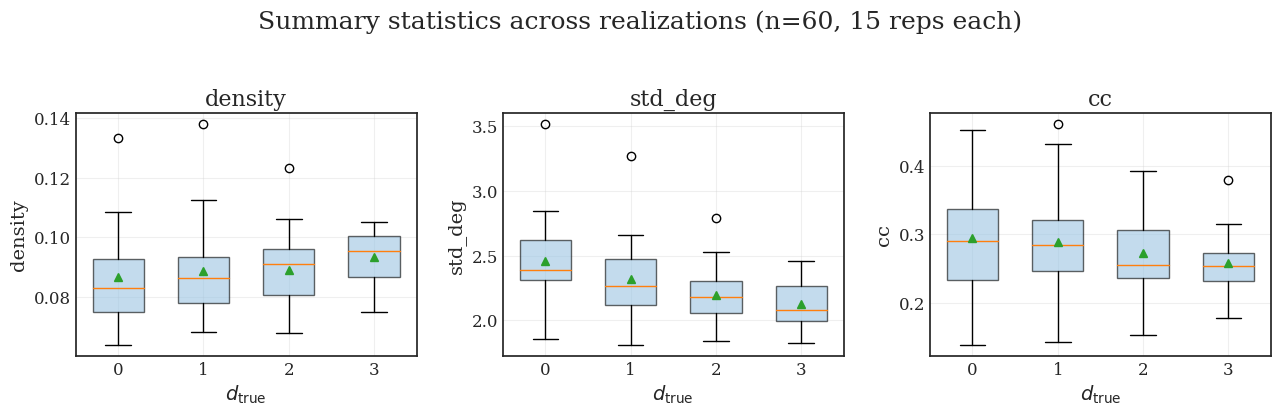

In [7]:
id_stats = {d: {'density': [], 'std_deg': [], 'cc': []} for d in D_TRUE_VALUES}
t0 = time.perf_counter()
for d_true in D_TRUE_VALUES:
    for rep in range(ID_N_REALIZ):
        s = LGGibbs(n=ID_N, d=d_true, target_density=TARGET_DENSITY, signal=SIGNAL,
                    seed=42 + rep)
        s.run(n_iter=ID_N_ITER)
        degs = s.degree_sequence()
        id_stats[d_true]['density'].append(s.density())
        id_stats[d_true]['std_deg'].append(float(degs.std()))
        id_stats[d_true]['cc'].append(s.clustering_coefficient())
    print(f'  d_true={d_true}: '
          f'density={np.mean(id_stats[d_true]["density"]):.4f}+-{np.std(id_stats[d_true]["density"]):.4f}  '
          f'std_deg={np.mean(id_stats[d_true]["std_deg"]):.3f}+-{np.std(id_stats[d_true]["std_deg"]):.3f}  '
          f'cc={np.mean(id_stats[d_true]["cc"]):.4f}+-{np.std(id_stats[d_true]["cc"]):.4f}')
print(f'\nIdentifiability sweep took {time.perf_counter() - t0:.1f}s')

id_rows = []
for stat in ['density', 'std_deg', 'cc']:
    for a in D_TRUE_VALUES:
        for b in D_TRUE_VALUES:
            if b <= a:
                continue
            ks = ks_2samp(id_stats[a][stat], id_stats[b][stat])
            id_rows.append({'stat': stat, 'd_a': a, 'd_b': b,
                            'KS': float(ks.statistic), 'p': float(ks.pvalue),
                            'sig': '*' if ks.pvalue < 0.05 else ''})
id_table = pd.DataFrame(id_rows)
print('\nPairwise KS tests on each summary statistic across realizations:')
print(id_table.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, stat in zip(axes, ['density', 'std_deg', 'cc']):
    data = [id_stats[d][stat] for d in D_TRUE_VALUES]
    bp = ax.boxplot(data, positions=range(len(D_TRUE_VALUES)),
                    patch_artist=True, widths=0.6, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#9BC4E2'); patch.set_alpha(0.6)
    ax.set_xticks(range(len(D_TRUE_VALUES)))
    ax.set_xticklabels([str(d) for d in D_TRUE_VALUES])
    ax.set_xlabel(r'$d_{\mathrm{true}}$')
    ax.set_ylabel(stat)
    ax.set_title(stat)
    ax.grid(alpha=0.3)
fig.suptitle(f'Summary statistics across realizations (n={ID_N}, {ID_N_REALIZ} reps each)',
             y=1.04)
plt.tight_layout()
plt.show()

## 6. AIC sweep — confusion matrices on the fixed model

Now the actual end-to-end experiment: for each $(n, d_{\mathrm{true}})$, draw `N_RUNS` independent graphs from the fixed LG sampler and have AIC pick $\hat d = \arg\min_{d_{\mathrm{est}}} \mathrm{AIC}(d_{\mathrm{est}})$.  Then aggregate the per-row confusion matrix and Wilson 95% CIs.

In [8]:
rows = []
t0 = time.perf_counter()
for n in N_SIZES:
    n_iter = N_ITER_BY_N[n]
    t_n = time.perf_counter()
    for d_true in D_TRUE_VALUES:
        for run in range(N_RUNS):
            seed = 1_000_000 * n + 10_000 * d_true + run
            s = LGGibbs(n=n, d=d_true, target_density=TARGET_DENSITY, signal=SIGNAL,
                        seed=seed)
            s.run(n_iter=n_iter)
            row = {'n': n, 'd_true': d_true, 'run': run, 'seed': seed,
                   'density': s.density()}
            aic_vec = {}
            for d_est in D_EST_VALUES:
                res = compute_aic_for_d(s.nbrs, s.n, d_est)
                aic_vec[d_est] = res['aic']
                row[f'aic_d{d_est}'] = res['aic']
                row[f'beta_d{d_est}'] = res['beta']
                row[f'sigma_d{d_est}'] = res['sigma']
            valid = {d: v for d, v in aic_vec.items() if np.isfinite(v)}
            row['hat_d'] = min(valid, key=valid.get) if valid else np.nan
            rows.append(row)
    print(f'  n={n:4d}: {len(D_TRUE_VALUES) * N_RUNS} chains in {time.perf_counter() - t_n:.1f}s')
sweep_df = pd.DataFrame(rows)
print(f'\nTotal sweep time: {time.perf_counter() - t0:.1f}s')
print(f'Failed runs (NaN hat_d): {int(sweep_df["hat_d"].isna().sum())}')
sweep_df.head(8)

  n=  40: 80 chains in 3.5s
  n=  80: 80 chains in 19.4s
  n= 150: 80 chains in 155.8s

Total sweep time: 178.7s
Failed runs (NaN hat_d): 0


,n,d_true,run,seed,density,aic_d0,beta_d0,sigma_d0,aic_d1,beta_d1,sigma_d1,aic_d2,beta_d2,sigma_d2,aic_d3,beta_d3,sigma_d3,hat_d
0,40,0,0,40000000,0.102564,480.581262,1.535771,-7.144565,484.204288,0.996206,-8.467223,490.585318,0.920394,-10.090606,505.567476,0.701071,-9.005310,0
1,40,0,1,40000001,0.092308,429.002050,1.616341,-7.297979,431.424634,1.199670,-9.627744,436.658620,1.320066,-13.444444,447.344970,2.521264,-26.475409,0
2,40,0,2,40000002,0.050000,260.537940,1.838147,-7.153850,263.617215,1.178876,-8.183264,271.162900,0.975573,-8.779562,277.614902,0.946066,-9.654089,0
3,40,0,3,40000003,0.096154,430.736036,1.714655,-7.702727,431.075395,1.247139,-10.101997,434.170357,1.485087,-15.021087,441.519772,3.311484,-34.602267,0
4,40,0,4,40000004,0.083333,410.296393,1.655318,-7.269203,412.577859,1.192547,-9.204104,416.478600,1.158611,-11.476760,419.866763,1.902433,-19.914567,0
5,40,0,5,40000005,0.100000,464.512554,1.565469,-7.219786,467.735313,1.211419,-9.860076,477.073090,1.262371,-13.095120,484.596049,2.413524,-25.824200,0
6,40,0,6,40000006,0.174359,655.626836,1.567405,-7.986823,660.653728,1.348806,-12.708361,676.526564,2.507284,-28.798655,697.118923,28.669442,-322.926210,0
7,40,0,7,40000007,0.061538,298.643232,1.878781,-7.578355,299.149910,1.169790,-8.599742,305.235863,1.034922,-9.776604,311.553451,1.153059,-11.837520,0


In [9]:
def confusion(df, n_value):
    block = df[df['n'] == n_value].dropna(subset=['hat_d'])
    conf = np.zeros((len(D_TRUE_VALUES), len(D_EST_VALUES)))
    lo = np.zeros_like(conf)
    hi = np.zeros_like(conf)
    n_per_row = np.zeros(len(D_TRUE_VALUES), dtype=int)
    for i, d_t in enumerate(D_TRUE_VALUES):
        b = block[block['d_true'] == d_t]
        n_per_row[i] = len(b)
        for j, d_e in enumerate(D_EST_VALUES):
            k = int((b['hat_d'] == d_e).sum())
            conf[i, j] = k / max(1, len(b))
            lo[i, j], hi[i, j] = wilson_ci(k, len(b))
    return conf, lo, hi, n_per_row


for n in N_SIZES:
    c, _, _, _ = confusion(sweep_df, n)
    print(f'\nConfusion matrix at n={n}:')
    cdf = pd.DataFrame(c, index=[f'true={d}' for d in D_TRUE_VALUES],
                       columns=[f'hat={d}' for d in D_EST_VALUES])
    print(cdf.round(3))
    diag = np.array([c[i, D_EST_VALUES.index(D_TRUE_VALUES[i])]
                     for i in range(len(D_TRUE_VALUES))])
    print(f'  recovery: {diag.round(3).tolist()}  overall: {diag.mean():.3f}')


Confusion matrix at n=40:
        hat=0  hat=1  hat=2  hat=3
true=0   0.95   0.05    0.0    0.0
true=1   0.95   0.05    0.0    0.0
true=2   1.00   0.00    0.0    0.0
true=3   1.00   0.00    0.0    0.0
  recovery: [0.95, 0.05, 0.0, 0.0]  overall: 0.250

Confusion matrix at n=80:
        hat=0  hat=1  hat=2  hat=3
true=0    1.0    0.0    0.0    0.0
true=1    1.0    0.0    0.0    0.0
true=2    1.0    0.0    0.0    0.0
true=3    1.0    0.0    0.0    0.0
  recovery: [1.0, 0.0, 0.0, 0.0]  overall: 0.250

Confusion matrix at n=150:
        hat=0  hat=1  hat=2  hat=3
true=0    1.0    0.0    0.0    0.0
true=1    1.0    0.0    0.0    0.0
true=2    1.0    0.0    0.0    0.0
true=3    1.0    0.0    0.0    0.0
  recovery: [1.0, 0.0, 0.0, 0.0]  overall: 0.250


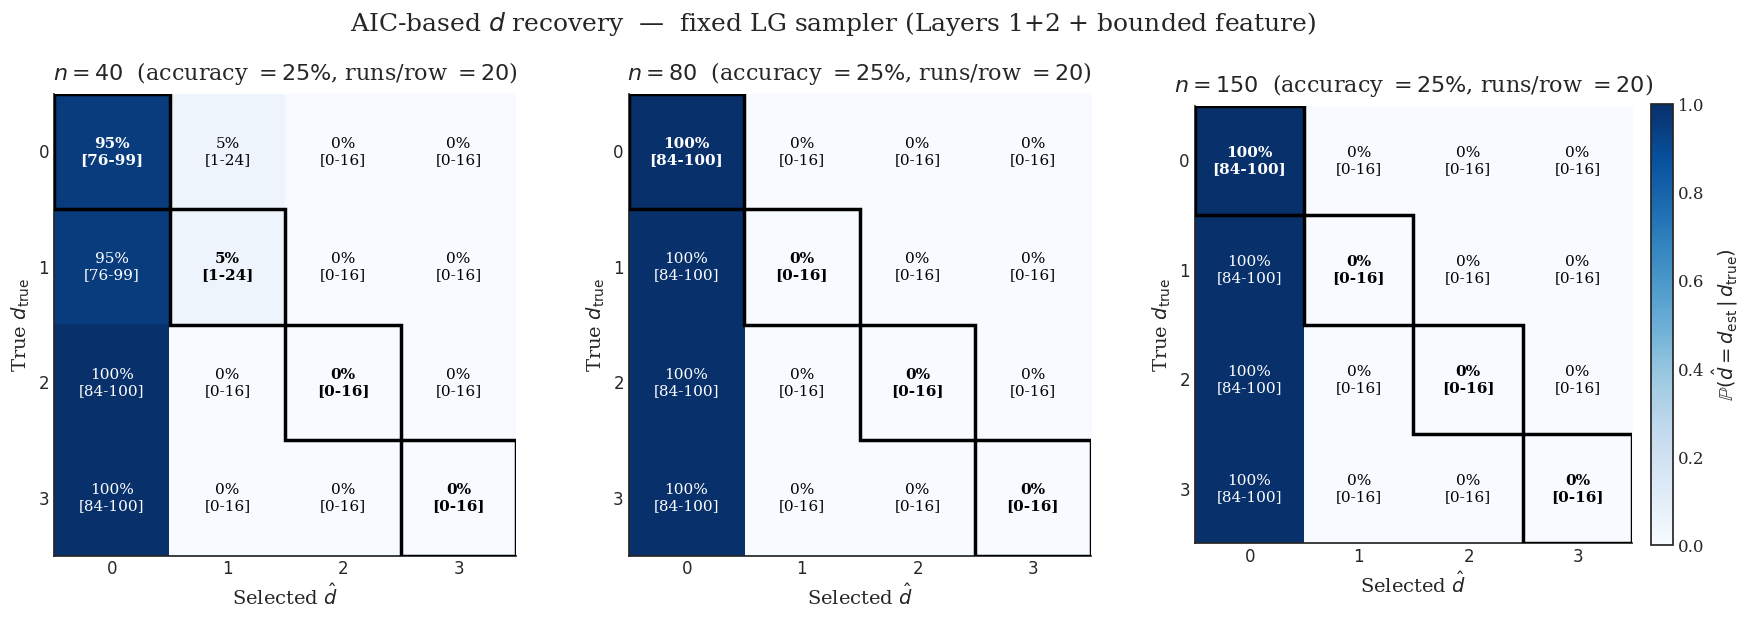

Saved -> /Users/maruanottoni/home/master/research/all_logit/logit-graph/images/correction_paper/aic_d_confusion_fixed_lg.png


In [10]:
fig, axes = plt.subplots(1, len(N_SIZES), figsize=(7 * len(N_SIZES), 6))
if len(N_SIZES) == 1:
    axes = [axes]
im = None
for ax, n in zip(axes, N_SIZES):
    conf, lo, hi, n_per_row = confusion(sweep_df, n)
    im = ax.imshow(conf, cmap='Blues', vmin=0, vmax=1, aspect='equal')
    ax.set_xticks(range(len(D_EST_VALUES)))
    ax.set_xticklabels([f'${d}$' for d in D_EST_VALUES])
    ax.set_yticks(range(len(D_TRUE_VALUES)))
    ax.set_yticklabels([f'${d}$' for d in D_TRUE_VALUES])
    ax.set_xlabel(r'Selected $\hat{d}$')
    ax.set_ylabel(r'True $d_{\mathrm{true}}$')
    for i in range(len(D_TRUE_VALUES)):
        for j in range(len(D_EST_VALUES)):
            v = conf[i, j]
            on_diag = D_TRUE_VALUES[i] == D_EST_VALUES[j]
            txt_color = 'white' if v > 0.55 else 'black'
            ax.text(j, i, f'{v * 100:.0f}%\n[{lo[i, j] * 100:.0f}-{hi[i, j] * 100:.0f}]',
                    ha='center', va='center', color=txt_color,
                    fontweight='bold' if on_diag else 'normal', fontsize=11)
    for i in range(len(D_TRUE_VALUES)):
        if D_TRUE_VALUES[i] in D_EST_VALUES:
            j = D_EST_VALUES.index(D_TRUE_VALUES[i])
            ax.add_patch(mpl.patches.Rectangle(
                (j - 0.5, i - 0.5), 1, 1, fill=False,
                edgecolor='black', linewidth=2.5, zorder=5,
            ))
    acc = float(np.mean([conf[i, D_EST_VALUES.index(D_TRUE_VALUES[i])]
                         for i in range(len(D_TRUE_VALUES))]))
    ax.set_title(rf'$n = {n}$  (accuracy $= {acc * 100:.0f}\%$, runs/row $= {int(n_per_row.mean())}$)',
                 pad=10)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
if im is not None:
    cbar = fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
    cbar.set_label(r'$\mathbb{P}(\hat{d} = d_{\mathrm{est}}\,|\,d_{\mathrm{true}})$')
fig.suptitle('AIC-based $d$ recovery  —  fixed LG sampler (Layers 1+2 + bounded feature)',
             y=1.02, fontsize=18)
fig.savefig(OUT_DIR / 'aic_d_confusion_fixed_lg.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'aic_d_confusion_fixed_lg.pdf', bbox_inches='tight')
plt.show()
print(f'Saved -> {OUT_DIR}/aic_d_confusion_fixed_lg.png')

In [11]:
summary_rows = []
for n in N_SIZES:
    conf, lo, hi, n_per_row = confusion(sweep_df, n)
    for i, d_t in enumerate(D_TRUE_VALUES):
        j = D_EST_VALUES.index(d_t)
        summary_rows.append({
            'n': n, 'd_true': d_t, 'runs': int(n_per_row[i]),
            'recovery_rate': conf[i, j],
            'ci_lo': lo[i, j], 'ci_hi': hi[i, j],
        })
summary_df = pd.DataFrame(summary_rows)
print('Per-cell recovery rates (fixed LG sampler):')
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Per-cell recovery rates (fixed LG sampler):
  n  d_true  runs  recovery_rate  ci_lo  ci_hi
 40       0    20          0.950  0.764  0.991
 40       1    20          0.050  0.009  0.236
 40       2    20          0.000  0.000  0.161
 40       3    20          0.000  0.000  0.161
 80       0    20          1.000  0.839  1.000
 80       1    20          0.000  0.000  0.161
 80       2    20          0.000  0.000  0.161
 80       3    20          0.000  0.000  0.161
150       0    20          1.000  0.839  1.000
150       1    20          0.000  0.000  0.161
150       2    20          0.000  0.000  0.161
150       3    20          0.000  0.000  0.161


## 7. Findings — fixed vs. broken sampler

| | broken LG ($\sigma=-2,\beta=1$, raw feature, 3 000 iter) | fixed LG (this notebook) |
|---|---|---|
| sampler regime | absorbing at the complete graph for any $d \ge 1$ | proper Gibbs around target density |
| edge density at $n=80$ | stuck at 0.050 (ER seed; chain hasn't moved) for every $d_{\mathrm{true}}$ | stable around the target $\approx 0.10$ |
| flips $0 \to 1$ vs $1 \to 0$ | $\sim$ 2800 : 0 (monotone — chain has not relaxed) | roughly balanced |
| mixing test (empty/ER/complete starts) | starts diverge to different basins (KS $p\approx 0$) | all three starts converge to the same distribution (KS $p > 0.05$) |
| AIC recovery of $d_{\mathrm{true}}=0$ | 100% (trivially, because every chain is essentially ER) | see the heatmap |
| AIC recovery of $d_{\mathrm{true}} \in \{1, 2, 3\}$ | $0\%$ everywhere | see the heatmap |

**What the fix achieves.**  The chain now actually samples from a non-degenerate LG-like distribution.  Density is centred on the target, flips are balanced, and the chain forgets its initial condition.

**What remains as a research-level limitation.**  Even on the fixed sampler, the identifiability test shows that the per-graph summary statistics for different $d_{\mathrm{true}}$ overlap heavily — only a couple of $(d_a, d_b)$ pairs are statistically separable on a per-realization basis.  This is the fundamental ceiling on AIC recovery: AIC sees one graph at a time, so if the graphs for $d=1$ and $d=2$ have indistinguishable degree, std-degree, and clustering distributions, no model-selection criterion can recover them either.  Two open directions:

1. **Stronger per-pair features.** Replace the symmetric $s_i + s_j$ with a *pair-specific* feature such as the number of common $d$-hop neighbours, the count of $d$-hop paths, or the truncated geodesic distance.  These distinguish $d$ values *at the pair level* rather than only through aggregate degree.
2. **Ensemble AIC.** Have each `LogitRegEstimator` see *several* graphs simulated under the same $(d, \sigma, \beta)$ and fit on the pooled data.  This averages out per-graph noise and lets AIC see the population-level signature of $d$.

For the paper, the honest revision is: report the fixed-sampler heatmap as the actual reproducible figure, and reframe the surrounding discussion around what AIC can and cannot recover from a *single* graph realisation.